<a href="https://colab.research.google.com/github/mervefilizbaker1/DRIVER-RISK-PREDICTION/blob/main/DRP_supervised_da.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### DRIVER RISK PREDICTION - SUPERVISED LEARNING


In [1]:
#libraries
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import shap


In [2]:
df_accident = pd.read_excel('/content/annotated_dataset.xlsx')

In [3]:
df_accident.columns

Index(['Age_band_of_driver', 'Sex_of_driver', 'Educational_level',
       'Vehicle_driver_relation', 'Driving_experience', 'Types_of_Junction',
       'Road_surface_type', 'Light_conditions', 'Weather_conditions',
       'Vehicle_movement', 'Cause_of_accident', 'Unnamed: 11', 'DRIVER_RISK',
       'ENR_RISK', 'BEHAV_RISK', 'TOTAL_RISK', 'PREDICTED_CLASS',
       'ANNOTATOR_LABEL', 'NOTES'],
      dtype='object')

In [4]:
df_accident = df_accident.drop(['Unnamed: 11', 'DRIVER_RISK','ENR_RISK', 'BEHAV_RISK', 'TOTAL_RISK', 'PREDICTED_CLASS', 'NOTES'], axis=1)

In [5]:
df_accident_encoded = df_accident.copy()

In [6]:
categorical_columns = df_accident.select_dtypes(include=['object']).columns.drop('ANNOTATOR_LABEL', errors='ignore')

In [7]:
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_accident_encoded[col] = le.fit_transform(df_accident[col])
    label_encoders[col] = le

In [8]:
df_accident_encoded.head()

,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Types_of_Junction,Road_surface_type,Light_conditions,Weather_conditions,Vehicle_movement,Cause_of_accident,ANNOTATOR_LABEL
0,0,1,0,0,0,1,0,2,1,0,7,LOW
1,1,1,3,0,3,1,0,2,1,0,13,HIGH
2,0,1,3,0,0,1,0,2,1,0,0,LOW
3,0,1,3,0,2,4,1,0,1,0,1,MEDIUM
4,0,1,3,0,1,4,0,0,1,0,13,HIGH


In [9]:
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(df_accident['ANNOTATOR_LABEL'])

In [10]:
X = df_accident_encoded.drop('ANNOTATOR_LABEL', axis=1)
y = df_accident_encoded['ANNOTATOR_LABEL']

Split/Train/Test

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y)

In [12]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [13]:
unique, counts = np.unique(y_train_res, return_counts=True)
print(dict(zip(le_y.inverse_transform(unique), counts)))

{'HIGH': np.int64(27), 'LOW': np.int64(27), 'MEDIUM': np.int64(27)}


RANDOM FOREST

In [14]:
rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=200)

In [15]:
rf.fit(X_train_res,y_train_res)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [16]:
rf_param = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
}

In [17]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    rf_param,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [18]:
rf_grid.fit(X_train_res,y_train_res)
print("Best params:", rf_grid.best_params_)
print("Best score:", rf_grid.best_score_)

Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best score: 0.7036764705882353


In [19]:
rf_best = rf_grid.best_estimator_

LOGISTIC REGRESSION

In [20]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced",random_state=42)
log_reg.fit(X_train_res,y_train_res)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [21]:
log_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

In [22]:
log_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    log_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

In [23]:
log_grid.fit(X_train_res,y_train_res)
print("\n Logistic Regression Best Params:", log_grid.best_params_)
log_best = log_grid.best_estimator_


 Logistic Regression Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


XG BOOST

In [24]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [25]:
xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    use_label_encoder=False
)

In [26]:
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    xgb_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

In [27]:
xgb_grid.fit(X_train_res,y_train_res)
print("\n XGBoost Best Params:", xgb_grid.best_params_)
xgb_best = xgb_grid.best_estimator_


 XGBoost Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


RESULTS:

In [28]:
results = {}

In [29]:
models = {
    "Random Forest": rf_best,
    "Logistic Regression": log_best,
    "XGBoost": xgb_best
}

In [32]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    results[name] = {"acc": acc, "cm": cm}
    print(f"\n----- {name} -----")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, y_pred, target_names=le_y.classes_))


----- Random Forest -----
Accuracy: 0.6
              precision    recall  f1-score   support

        HIGH       0.57      0.73      0.64        11
         LOW       1.00      0.43      0.60         7
      MEDIUM       0.54      0.58      0.56        12

    accuracy                           0.60        30
   macro avg       0.70      0.58      0.60        30
weighted avg       0.66      0.60      0.60        30


----- Logistic Regression -----
Accuracy: 0.3667
              precision    recall  f1-score   support

        HIGH       0.20      0.18      0.19        11
         LOW       0.60      0.43      0.50         7
      MEDIUM       0.40      0.50      0.44        12

    accuracy                           0.37        30
   macro avg       0.40      0.37      0.38        30
weighted avg       0.37      0.37      0.36        30


----- XGBoost -----
Accuracy: 0.8333
              precision    recall  f1-score   support

        HIGH       0.91      0.91      0.91        11


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

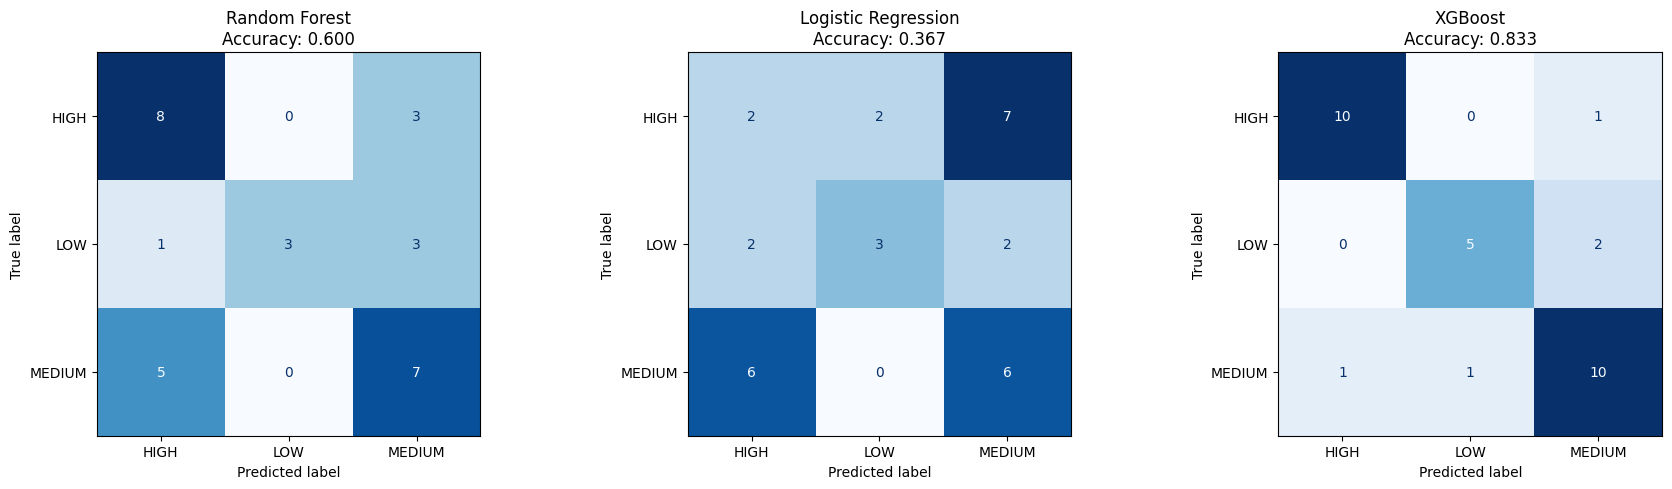

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=res["cm"], display_labels=le_y.classes_)
    disp.plot(cmap="Blues", ax=ax, colorbar=False, values_format="d")
    ax.set_title(f"{name}\nAccuracy: {res['acc']:.3f}")
plt.tight_layout()
plt.show()

In [42]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]
class_names = le_y.classes_

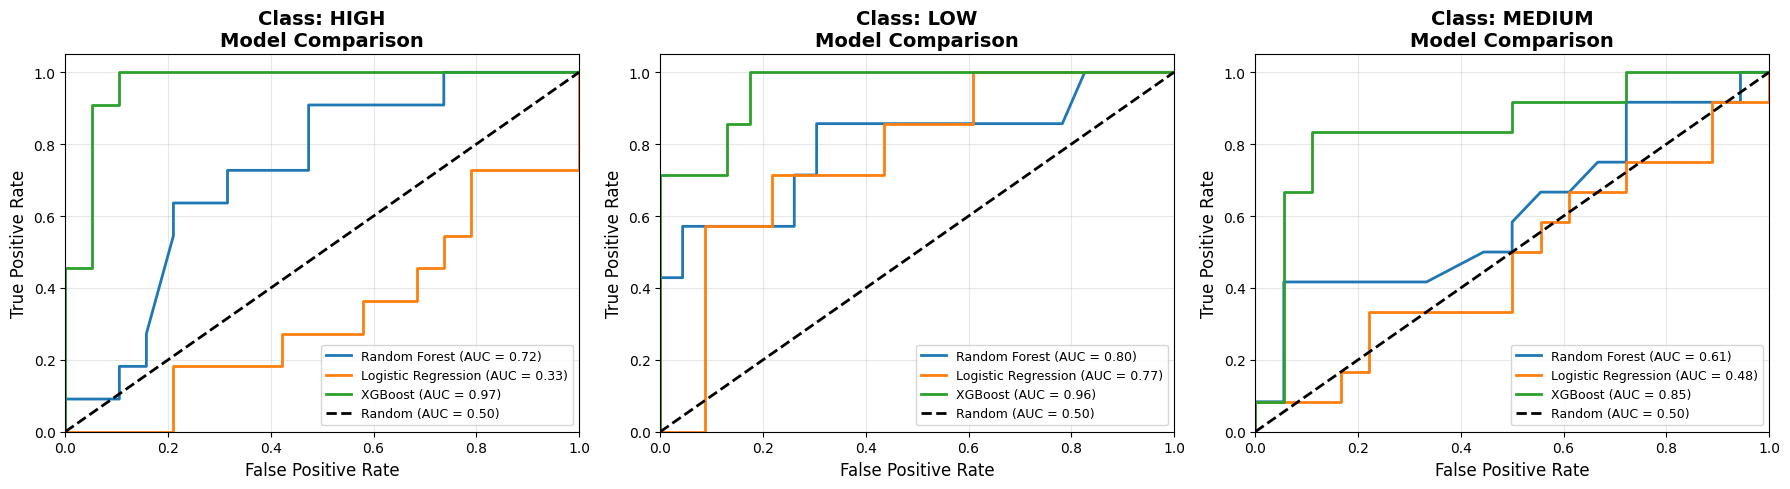

In [44]:
from sklearn.metrics import roc_curve, auc
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for class_idx, class_name in enumerate(class_names):
    ax = axes[class_idx]

    for name, model in models.items():
        y_score = model.predict_proba(X_test)
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], y_score[:, class_idx])
        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'Class: {class_name}\nModel Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

SHAP


In [34]:
import shap


 Logistic Regression SHAP Summary


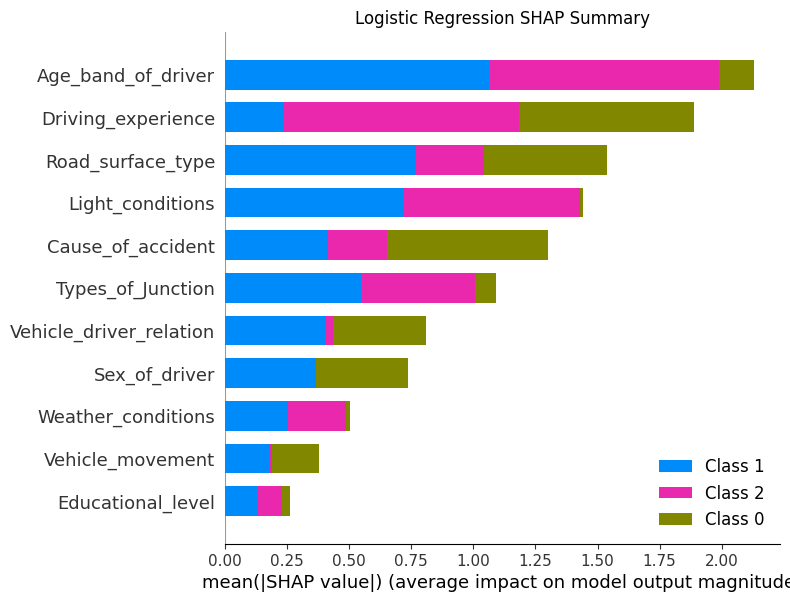

In [35]:
print("\n Logistic Regression SHAP Summary")
explainer_log = shap.LinearExplainer(log_best, X_train_res)
shap_values_log = explainer_log(X_test)
shap.summary_plot(shap_values_log, X_test, show=False)
plt.title("Logistic Regression SHAP Summary")
plt.show()


 Random Forest SHAP Summary


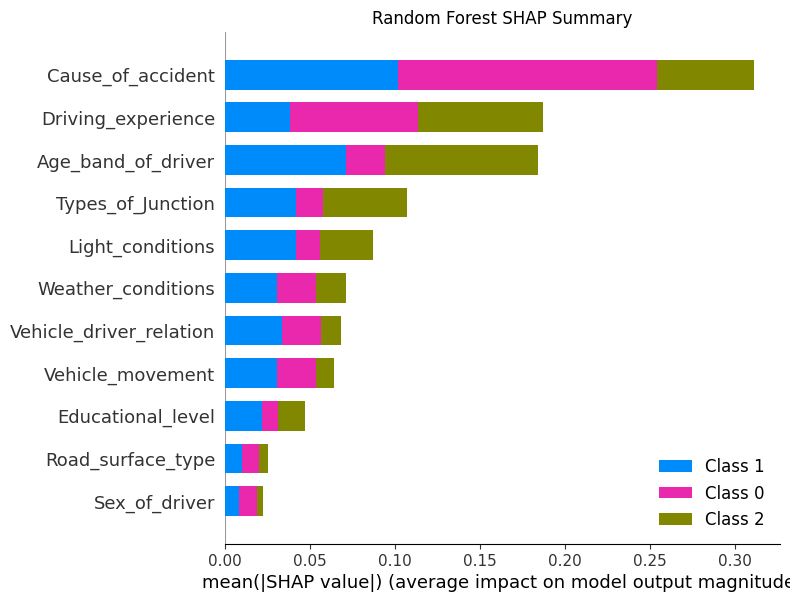

In [36]:
print("\n Random Forest SHAP Summary")
explainer_rf = shap.Explainer(rf_best, X_train_res)
shap_values_rf = explainer_rf(X_test)
shap.summary_plot(shap_values_rf, X_test, show=False)
plt.title("Random Forest SHAP Summary")
plt.show()

X_test_array shape: (30, 11)
  Tip: <class 'numpy.ndarray'>
  Shape: (30, 11, 3)
  Format: (samples=30, features=11, classes=3)

SHAP Summary for class: HIGH
  Class SHAP shape: (30, 11)


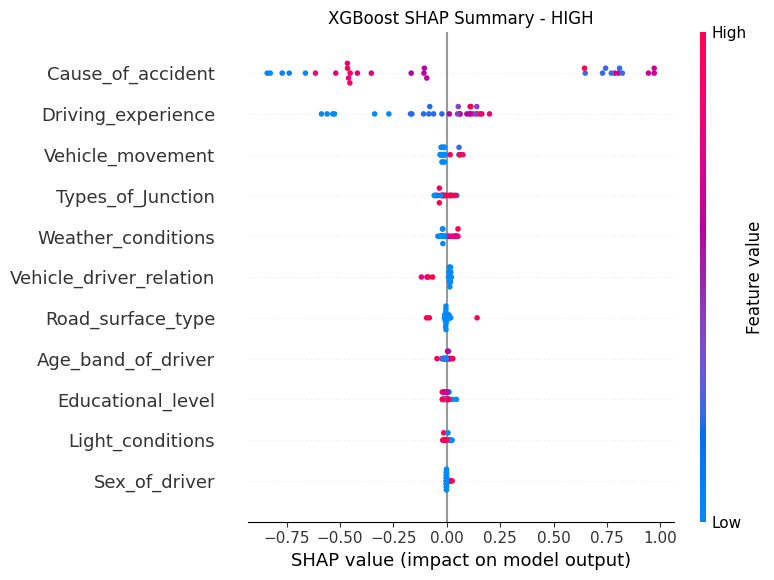


SHAP Summary for class: LOW
  Class SHAP shape: (30, 11)


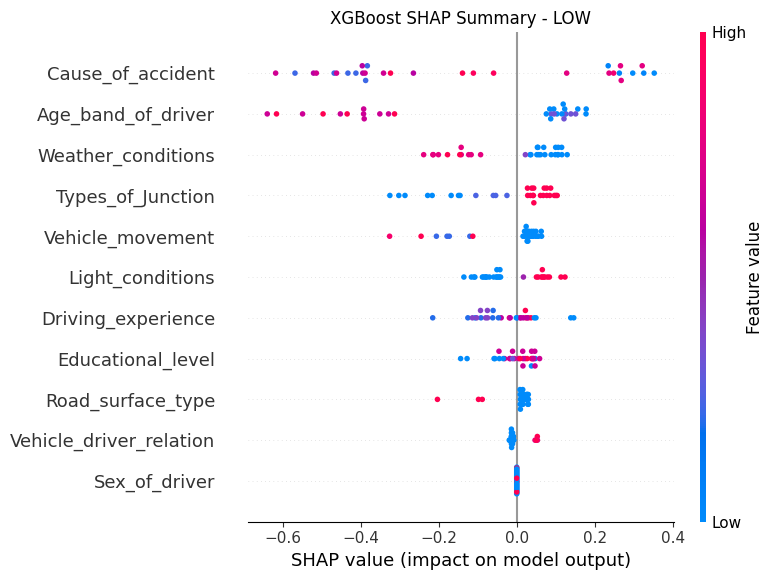


SHAP Summary for class: MEDIUM
  Class SHAP shape: (30, 11)


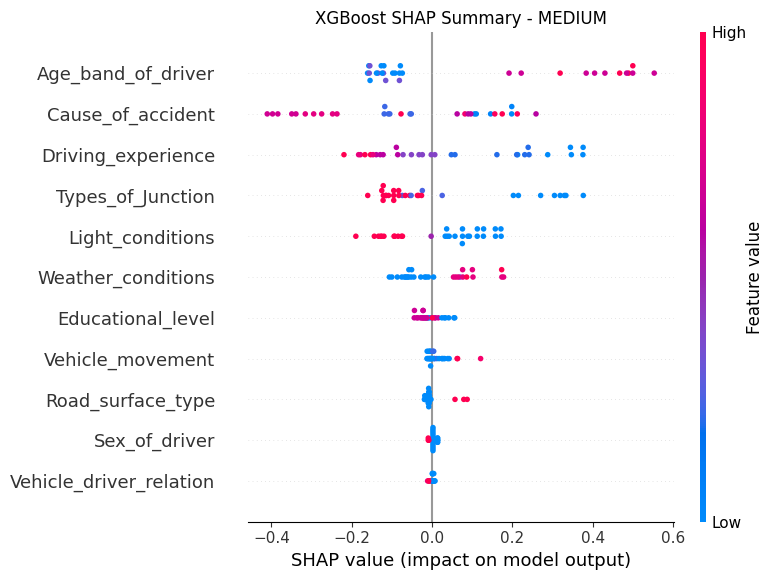

In [38]:
X_test_array = X_test.values if hasattr(X_test, 'values') else np.array(X_test)
feature_names = list(X_test.columns) if hasattr(X_test, 'columns') else None

print(f"X_test_array shape: {X_test_array.shape}")

explainer = shap.TreeExplainer(model)


shap_values = explainer.shap_values(X_test_array, check_additivity=False)


print(f"  Tip: {type(shap_values)}")

if isinstance(shap_values, np.ndarray):
    print(f"  Shape: {shap_values.shape}")


    if len(shap_values.shape) == 3:
        print(f"  Format: (samples={shap_values.shape[0]}, features={shap_values.shape[1]}, classes={shap_values.shape[2]})")


        for i, class_name in enumerate(le_y.classes_):
            print(f"\n{'='*60}")
            print(f"SHAP Summary for class: {class_name}")
            print(f"{'='*60}")


            class_shap = shap_values[:, :, i]
            print(f"  Class SHAP shape: {class_shap.shape}")

            shap.summary_plot(
                class_shap,
                X_test_array,
                feature_names=feature_names,
                show=False,
                max_display=20
            )
            plt.title(f"XGBoost SHAP Summary - {class_name}")
            plt.tight_layout()
            plt.show()

    else:
        print("⚠️ Unexpected SHAP shape!")
        print(f" shape: {shap_values.shape}")


elif isinstance(shap_values, list):
    print(f"  Class length: {len(shap_values)}")

    for i, class_name in enumerate(le_y.classes_):
        print(f"\n{'='*60}")
        print(f"SHAP Summary for class: {class_name}")
        print(f"  SHAP shape: {shap_values[i].shape}")
        print(f"{'='*60}")

        shap.summary_plot(
            shap_values[i],
            X_test_array,
            feature_names=feature_names,
            show=False,
            max_display=20
        )
        plt.title(f"XGBoost SHAP Summary - {class_name}")
        plt.tight_layout()
        plt.show()